# Introduction to Data Science — Homework 4
*MATH 4100 / COMP 5360, University of Utah, http://datasciencecourse.net/*

**Due:** Friday, February 6, 2026, 11:59 PM

In this assignment, you will analyze air quality data from Salt Lake City and perform an A/B test to compare the performance of two advertisements.

## Your Information

Please fill in the following details:

- **First Name:**  Ibrahim
- **Last Name:**  Ergin
- **Email:**  u1564808@utah.edu
- **UID:**  u1564808

In [20]:
# imports and setup 
import pandas as pd
import scipy as sc
from scipy.stats import norm
import numpy as np
from statsmodels.stats.proportion import proportions_ztest

import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.style.use('ggplot')


# Display settings for pandas DataFrames
# I' m using VSCode's Jupyter Notebook interface, so I want to see all the data without truncation.
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.max_rows', None) # Show all rows  
pd.set_option('display.width', None)    # No width limit
pd.set_option('display.max_colwidth', None) # Show full content
pd.set_option('display.expand_frame_repr', False)   # Don't wrap to multiple lines

## Part I: Salt Lake City Air Quality

In this part, you will study air quality data from Salt Lake City.

### Task 1.0: Learn About AQI

Read about the [Air Quality Index (AQI)](https://airnow.gov/index.cfm?action=aqibasics.aqi) and the [AirNow](https://airnow.gov/index.cfm?action=topics.about_airnow) system.

### Task 1.1: Download the Data

The Environmental Protection Agency (EPA) provides access to historical air quality data through the AirData website. First, read about the available datasets on [the EPA information page on basic air quality data](https://www.epa.gov/outdoor-air-quality-data/air-data-basic-information).

Next, go to [the EPA download page for air quality data](https://www.epa.gov/outdoor-air-quality-data/download-daily-data) and download the daily data with the following settings:

- **Pollutant:** PM2.5  
- **Year:** 2025  
- **City:** Salt Lake City, UT  
- **Monitor Site:** All Sites  

Rename the file to **SLC_PM2.5.csv**. Make sure you include it in the zip of your submission.



### Task 1.2: Import the Data

Use the `pandas.read_csv()` function to import the dataset.

**Note:** The data are not fully cleaned. In particular:

- The dates are not sorted.  
- Some dates contain missing values.  
- Some dates have multiple measurements corresponding to different sensors (`POC = 1, 2, 3, 4, 5`) and different monitoring sites.  

In [21]:
df = pd.read_csv('SLC_PM2.5.csv')
print("Dataset has", df.shape[0], "rows and", df.shape[1], "columns.")
print("\nData info:")
print(df.info())
print("*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-")
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())
print("*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-")
print("\nBasic statistics:")
print(df.describe())

Dataset has 6870 rows and 22 columns.

Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6870 entries, 0 to 6869
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Date                            6870 non-null   object 
 1   Source                          6870 non-null   object 
 2   Site ID                         6870 non-null   int64  
 3   POC                             6870 non-null   int64  
 4   Daily Mean PM2.5 Concentration  6870 non-null   float64
 5   Units                           6870 non-null   object 
 6   Daily AQI Value                 6870 non-null   int64  
 7   Local Site Name                 6870 non-null   object 
 8   Daily Obs Count                 6870 non-null   int64  
 9   Percent Complete                6870 non-null   float64
 10  AQS Parameter Code              6870 non-null   int64  
 11  AQS Parameter Description       6870 non-null

Date 's type is **object**. We need to convert it to **datetime**.

In [22]:
df['Date'] = pd.to_datetime(df['Date'])
print(df['Date'].dtype)

# Check for missing values in the 'Date' column
print("First date:", df['Date'].min())
print("Last date:", df['Date'].max())
print("Total days:", (df['Date'].max() - df['Date'].min()).days + 1)    # +1 to include both start and end date

datetime64[ns]
First date: 2025-01-01 00:00:00
Last date: 2025-12-31 00:00:00
Total days: 365


In [23]:
measurements_per_date = df.groupby('Date').size()
print("Measurements per date (first 10 days):")
print(measurements_per_date.head(10))

print("\nMin measurements in a day:", measurements_per_date.min())
print("Max measurements in a day:", measurements_per_date.max())
print("Average measurements per day:", measurements_per_date.mean())

Measurements per date (first 10 days):
Date
2025-01-01    19
2025-01-02    19
2025-01-03    19
2025-01-04    19
2025-01-05    19
2025-01-06    19
2025-01-07    19
2025-01-08    19
2025-01-09    19
2025-01-10    19
dtype: int64

Min measurements in a day: 17
Max measurements in a day: 19
Average measurements per day: 18.82191780821918


In [24]:
# Example date (first date) to see all its measurements
example_date = df['Date'].iloc[0]  # Get the first date
print(f"First date: {example_date.date()}")
print(f"Number of measurements: {len(df[df['Date'] == example_date])}")

print("*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-")
# Show all measurements for example date (first date)
print(df[df['Date'] == example_date])
print("*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-")
# Show specific columns for the example date (first date)
one_day = df[df['Date'] == example_date][['Date', 'Site ID', 'POC', 'Daily Mean PM2.5 Concentration', 'Daily AQI Value', 'Local Site Name']]
print(one_day)

First date: 2025-01-01
Number of measurements: 19
*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-
           Date Source    Site ID  POC  Daily Mean PM2.5 Concentration     Units  Daily AQI Value        Local Site Name  Daily Obs Count  Percent Complete  AQS Parameter Code AQS Parameter Description  Method Code                                     Method Description  CBSA Code           CBSA Name  State FIPS Code State  County FIPS Code     County  Site Latitude  Site Longitude
0    2025-01-01    AQS  490352005    1                             5.2  ug/m3 LC               29            Copper View                1             100.0               88101  PM2.5 - Local Conditions        145.0  R & P Model 2025 PM-2.5 Sequential Air Sampler w/VSCC      41620  Salt Lake City, UT               49  Utah                35  Salt Lake      40.598056     -111.894167
364  2025-01-01    AQS  490352005    4                           

I chose an example date which is first date to see what its values. So we can see that for Site ID, we have 10 different Site Ids. And POC is between 1-3 and for the different sensors it detects different values. So it is better for us to use average.

### Task 1.3: Plot the Data

1. The dataset contains multiple PM2.5 concentration and AQI measurements for the same date, collected at different monitoring sites and using different sensors (POCs). Create a single figure showing the **average PM2.5 concentration** and **average AQI** as functions of date. The plot should allow a reader to determine the average PM2.5 concentration or AQI value on any given date.

2. Create a plot of **average PM2.5 concentration versus date** for two specific monitoring sites (Site IDs **490352005** and **490353016**). In this case, the average should be taken only over POCs. Display both sites in the same figure for comparison. *Hint:* Use the pandas `groupby()` function.


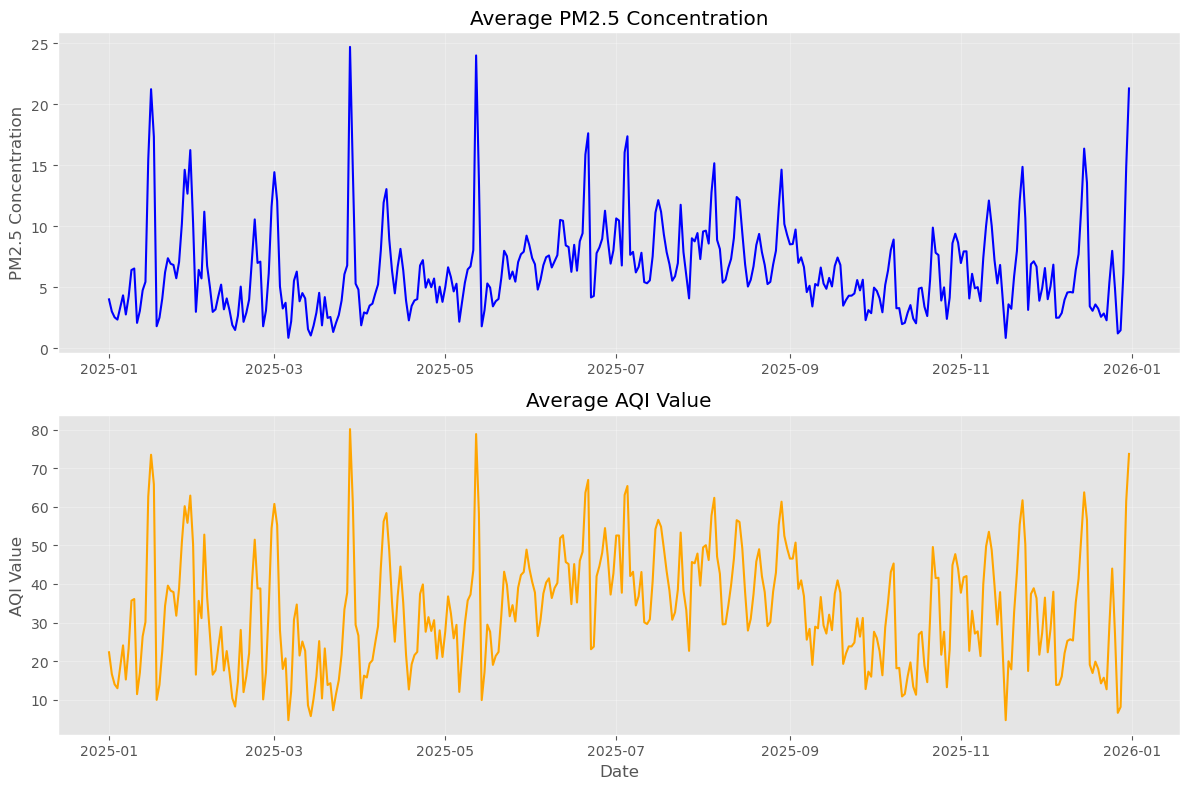

In [25]:
# Group by Date and calculate mean for PM2.5 and AQI
daily_avg = df.groupby('Date')[['Daily Mean PM2.5 Concentration', 'Daily AQI Value']].mean()


# Create two subplots (stacked vertically)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# PM2.5
ax1.plot(daily_avg.index, daily_avg['Daily Mean PM2.5 Concentration'], color='blue')
ax1.set_ylabel('PM2.5 Concentration')
ax1.set_title('Average PM2.5 Concentration')
ax1.grid(True, alpha=0.3)

# AQI
ax2.plot(daily_avg.index, daily_avg['Daily AQI Value'], color='orange')
ax2.set_xlabel('Date')
ax2.set_ylabel('AQI Value')
ax2.set_title('Average AQI Value')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

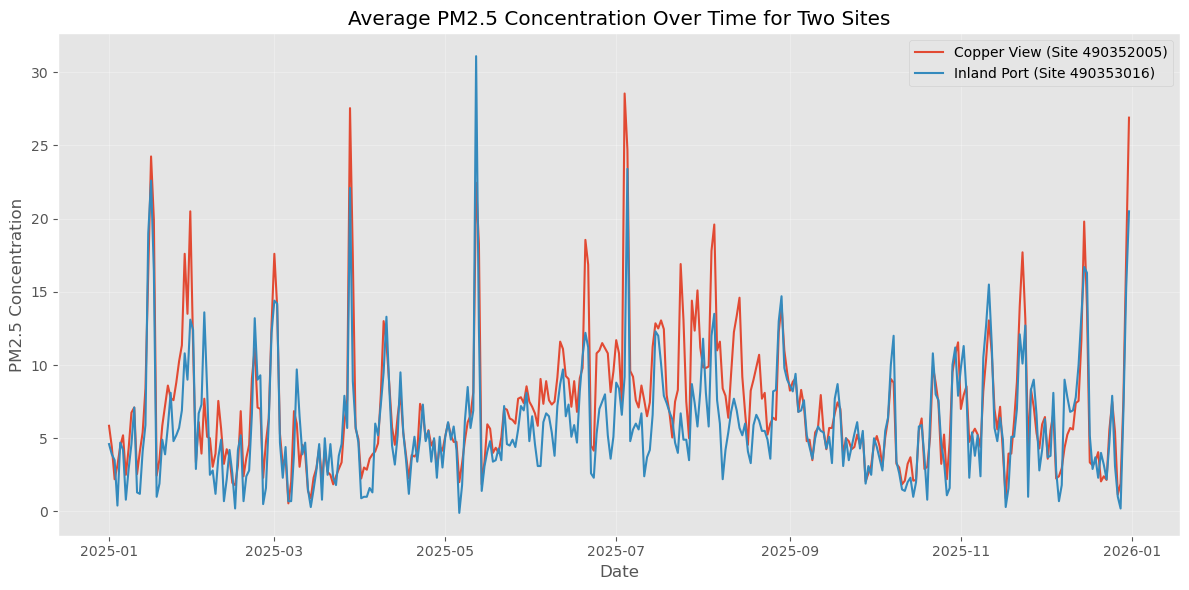

In [26]:
# Filter for the two specific sites
target_sites = [490352005, 490353016]
sites_df = df[df['Site ID'].isin(target_sites)].copy()

# Group by Date AND Site ID, average across POCs
site_daily_avg = sites_df.groupby(['Date', 'Site ID'])['Daily Mean PM2.5 Concentration'].mean().reset_index()

# Separate data for each site
site1_data = site_daily_avg[site_daily_avg['Site ID'] == 490352005]
site2_data = site_daily_avg[site_daily_avg['Site ID'] == 490353016]

# Get site names for legend
site1_name = sites_df[sites_df['Site ID'] == 490352005]['Local Site Name'].iloc[0]
site2_name = sites_df[sites_df['Site ID'] == 490353016]['Local Site Name'].iloc[0]

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(site1_data['Date'], site1_data['Daily Mean PM2.5 Concentration'], 
         label=f'{site1_name} (Site {490352005})', linewidth=1.5)
plt.plot(site2_data['Date'], site2_data['Daily Mean PM2.5 Concentration'], 
         label=f'{site2_name} (Site {490353016})', linewidth=1.5)

plt.xlabel('Date')
plt.ylabel('PM2.5 Concentration')
plt.title('Average PM2.5 Concentration Over Time for Two Sites')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Part II: A/B Testing 

First, read the [WIRED article on A/B testing](http://www.wired.com/2012/04/ff_abtesting/).

Suppose your company is developing a new logo. The art department designs two options: **Logo A** and **Logo B**, shown below.![Two logos for A/B testing](https://media.wired.com/photos/5a9f3fda52430e4b5eb949ab/3:2/w_1920,c_limit/ff_abtesting_f.jpg) Your task is to determine which logo performs better.

You decide to conduct the following experiment. Using Google Ads, you purchase 6,000 advertisements. In $N_A = 3{,}000$ of the ads (randomly selected), you display Logo A, and in the remaining $N_B = 3{,}000$ ads, you display Logo B. You then record how many users click on each ad.

The results show that $n_A = 800$ viewers clicked on ads with Logo A, while $n_B = 1{,}000$ viewers clicked on ads with Logo B. Clearly, Logo B received more clicks, but is this difference *statistically significant*? Or could Logo B have performed better purely by chance?

The goal of this part is to conduct a **two-proportion z-test** to determine whether Logo B truly outperforms Logo A. The steps will be similar to those discussed in Lecture 6 for the 1954 Salk polio vaccine experiment.

### Task 2.1: Formulate the Null and Alternative Hypotheses

Let $p_A = n_A / N_A$ denote the click-through rate (proportion of clicks) for Logo A, and similarly let $p_B = n_B / N_B$ denote the click-through rate for Logo B. In terms of $p_A$ and $p_B$, clearly state the **null hypothesis** and the **alternative hypothesis**.

**Your Solution:**  

$H_0: p_A = p_B$ 

$H_1: p_B > p_A$

Null Hypothesis ($H_0​$): Assumes there's NO difference between the logos. Both have the same click-through rate.
Alternative Hypothesis ($H_1$​): Assumes Logo B is better (has a higher click-through rate).

### Task 2.2.  Find the two-proportion z-value  

Assuming the null hypothesis, the test statistic—called the **two-proportion z-value**—is given by

$$Z = \frac{p_A - p_B}{\sqrt{\hat{p} \, \hat{q} \left( \frac{1}{N_A} + \frac{1}{N_B} \right)}},$$

and is approximately distributed according to the standard normal distribution. Here,  

$$\hat{p} = \frac{p_A N_A+p_B N_B}{N_A + N_B}, \quad \hat{q} = 1 - \hat{p}.$$

**Task:** Compute the two-proportion z-value for the given data.

In [27]:
N_A = 3000  # Number of ads with Logo A
n_A = 800   # Number of clicks on Logo A
N_B = 3000  # Number of ads with Logo B
n_B = 1000  # Number of clicks on Logo B


p_A = n_A / N_A
p_B = n_B / N_B

print(f"p_A = {p_A:.4f}")
print(f"p_B = {p_B:.4f}")
print("*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-")

p_hat = (n_A + n_B) / (N_A + N_B)
q_hat = 1 - p_hat
print(f"p_hat = {p_hat:.4f}")
print(f"q_hat = {q_hat:.4f}")
print("*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-")

# Calculate the Z-value using the formula
z = (p_A - p_B) / np.sqrt(p_hat * q_hat * (1/N_A + 1/N_B))

print(f"Z-value = {z:.4f}")

p_A = 0.2667
p_B = 0.3333
*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-
p_hat = 0.3000
q_hat = 0.7000
*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-
Z-value = -5.6344


### Task 2.3. Complete the two proportion z-test 

Find the $p$-value for the hypothesis test. Do this first using the normal cdf function and then check your answer by running a two proportions z-test in python with the proportions_ztest function. 

In [28]:
# For a two-tailed test, we need to consider both tails of the distribution. Since we're testing if p_A < p_B, we can calculate the p-value as:
p_value_manual = 2 * (1 - norm.cdf(abs(z)))
print("Method 1: Using norm.cdf()")
print(f"p-value = {p_value_manual}")

# Proportions_ztest with two-tailed
counts = [n_A, n_B]  # [800, 1000]
sample_sizes = [N_A, N_B]  # [3000, 3000]

# alternative='smaller' because we're testing if p_A < p_B
z_test, p_value_test = proportions_ztest(counts, sample_sizes, alternative='two-sided')

print("\nMethod 2: Using proportions_ztest()")
print(f"Z-value = {z_test:.4f}")
print(f"p-value = {p_value_test}")

Method 1: Using norm.cdf()
p-value = 1.7570790156185012e-08

Method 2: Using proportions_ztest()
Z-value = -5.6344
p-value = 1.7570790152024724e-08


### Task 2.4. Interpretation

Interpret the $p$-value in this example and  state the result of the hypothesis test at the $\alpha=10\%$ and $\alpha=5\%$ significance levels. 


**Your Interpretation:**  

The z-value of -5.63 (magnitude |z| = 5.63) indicates Logo A has significantly fewer clicks than Logo B. The p-value of 1.7570790152024724e-08 is much smaller than both significance levels.

**At $\alpha=5\%:$** We reject $H_0​$ but accept $H_1$. There is significant evidence that p_B > p_A.

**At $\alpha=10\%:$** We reject $H_0​$ but accept $H_1$. There is significant evidence that p_B > p_A.

    The magnitude of the z-value (5.63) shows an extremely strong difference. Logo B significantly outperforms Logo A. The company should choose Logo B.
